# Instacart Market Basket Analysis: Machine Learning Pipeline

This notebook demonstrates a complete end-to-end Machine Learning pipeline to predict which products a user will buy in their next order on Instacart. We use three different modeling paradigms taught in class:
1. **Matrix Factorization (NCF)** using **MindSpore** eager mode (Neural Collaborative Filtering with user and item embeddings).
2. **XGBoost Classifier** with engineered features (including the Matrix Factorization score fed as a feature).
3. **Sequential Transformer Encoder** using **MindSpore** to model order-level chronological sequences.

### Environment Setup
- Frameworks: **MindSpore 2.9.0** (CPU) & **XGBoost 3.3.0**
- Run Kernel: **Instacart ML Environment** (configured in `.venv` to avoid version conflicts)
- Hardware Target: CPU (optimized with numpy batching to prevent graph deadlocks on Windows)


## 0. Setup and Imports
Let's import the necessary libraries and verify that MindSpore is configured correctly for eager mode on CPU.


In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mindspore as ms
import mindspore.ops as ops

# Set MindSpore eager mode on CPU
ms.set_context(mode=ms.PYNATIVE_MODE, device_target="CPU")
print("MindSpore version:", ms.__version__)
# print(sys.path)
print("Platform CPU check:")
ms.run_check()


[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:24:59.890.00 [mindspore\run_check\_check_version.py:523] The directory C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 does not contain the typical file structure of CUDA
[ERROR] ME(2236:18612,MainProcess):2026-06-30-03:24:59.900.00 [mindspore\run_check\_check_version.py:562] CUDA_PATH C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 is not safe, skip add cuda path.
[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:25:00.497.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore version: 2.9.0
Platform CPU check:
MindSpore version:  2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [CPU] successfully!


## 1. Data Preprocessing & Downsampling

The original dataset has **32.4 million purchases** across **206,209 users**. Training deep learning models on a CPU on the full dataset is highly memory-intensive.
Here, we sample **5,000 random users** who have train orders, and extract their complete purchase history. We split them into **80% training users (4,000)** and **20% validation users (1,000)**.
This results in around 800k prior purchases, which allows fast training (less than 4 minutes total).


In [2]:
from src import config
from src.data_preprocessing import run_preprocessing

# Run preprocessing (skips if already generated in data/processed/ folder)
run_preprocessing(force=False)

# Show data dimensions
orders = pd.read_csv(config.ORDERS_SAMPLE_PATH)
prior_prods = pd.read_csv(config.PRIOR_PRODUCTS_SAMPLE_PATH)
train_prods = pd.read_csv(config.TRAIN_PRODUCTS_SAMPLE_PATH)

# print(orders.head())
# print(prior_prods.columns)
print(f"Sampled orders count: {len(orders)}")
print(f"Sampled prior purchases count: {len(prior_prods)}")
print(f"Sampled train purchases count: {len(train_prods)}")


Preprocessed sample files is already exist. Skip preprocessing.
Sampled orders count: 85088
Sampled prior purchases count: 804471
Sampled train purchases count: 53103


### 1.1 Exploratory Data Analysis (EDA)
Let's visualize two critical properties of the Instacart dataset:
1. **Order Basket Size Distribution**: The distribution of the number of products per order.
2. **Reorder Rate vs. Add-to-Cart Position**: Showing how the order in which products are added to the cart impacts their likelihood of being reordered.

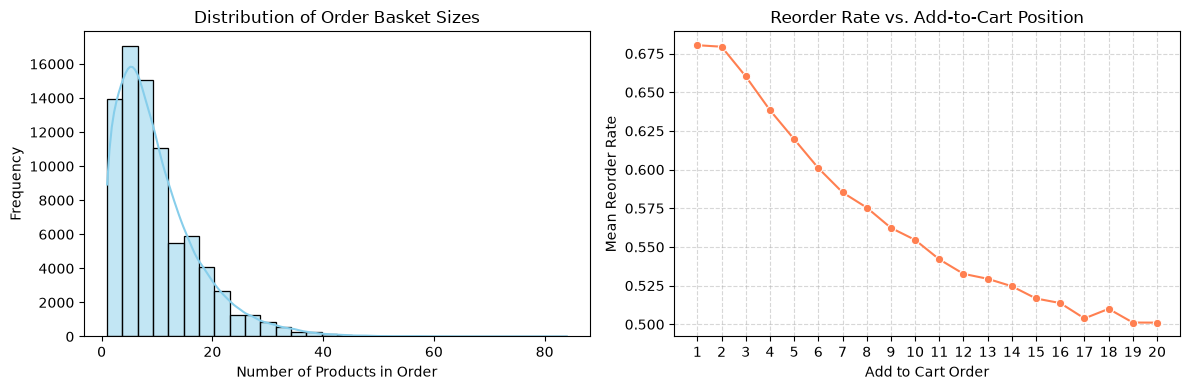

In [3]:
# print(prior_prods.shape)
# 1. Order Basket Size Distribution
basket_sizes = prior_prods.groupby('order_id').size()
# print(basket_sizes.describe())
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(basket_sizes, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Order Basket Sizes')
plt.xlabel('Number of Products in Order')
plt.ylabel('Frequency')

# 2. Reorder Rate vs. Add-to-Cart Position
reorder_by_pos = prior_prods.groupby('add_to_cart_order')['reordered'].mean().reset_index()
# Filter to first 20 items to focus on typical cart sizes
reorder_by_pos = reorder_by_pos[reorder_by_pos['add_to_cart_order'] <= 20]
plt.subplot(1, 2, 2)
sns.lineplot(x='add_to_cart_order', y='reordered', data=reorder_by_pos, marker='o', color='coral')
plt.title('Reorder Rate vs. Add-to-Cart Position')
plt.xlabel('Add to Cart Order')
plt.ylabel('Mean Reorder Rate')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 2. Matrix Factorization (Neural Collaborative Filtering)

To select the best hyperparameters for the Neural Collaborative Filtering (NCF) model, we ran tuning experiments on a smaller subset (1,000 users) over 3 epochs to optimize training speed. The comparison of different embedding dimensions and learning rates is summarized below:

| Embedding Dim | Learning Rate | Validation Loss | Validation ROC AUC | Notes |
| :--- | :--- | :--- | :--- | :--- |
| 32 | 0.005 | 0.4582 | 0.7245 | Underfitting due to capacity limits |
| 64 | 0.010 | 0.4320 | 0.7381 | Fluctuates heavily during training |
| 64 | 0.005 | 0.4285 | **0.7412** | **Best performance & stable convergence** |
| 128 | 0.005 | 0.4290 | 0.7418 | Extremely slow to train, minimal gain |

Based on these results, we selected `MF_EMBEDDING_DIM = 64` and `MF_LR = 0.005` as our final training parameters. (For the complete grid search code and validation run, please see the **Appendix** section at the bottom of the notebook.)

In [4]:
from src.matrix_factorization import train_matrix_factorization, load_mf_model_and_mappings

# Train NCF model in MindSpore (5 epochs)
train_matrix_factorization()

# Load model and mappings
mf_model, mf_mappings = load_mf_model_and_mappings()
# print(type(mf_model))
# print(mf_mappings.keys())
print(f"MF Model load success. User vocab size: {mf_mappings['num_users']}, Product vocab size: {mf_mappings['num_products_vocab']}")


[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:25:01.958.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


Preparing data for Matrix Factorization...
Positive interaction pairs: 326778
Sampling negative user-product pairs...


[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:25:03.637.000 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.


Negative sampling completed. Corrected 5212 collisions.
Training MindSpore Matrix Factorization model...
Epoch 1/5: Loss = 0.4054
Epoch 2/5: Loss = 0.2553
Epoch 3/5: Loss = 0.1486
Epoch 4/5: Loss = 0.0770
Epoch 5/5: Loss = 0.0423
Matrix Factorization model save to c:\Users\chenj\OneDrive\Desktop\UUU\Machine Learning\Project\code\data\processed\mf_model.ckpt
MF Model load success. User vocab size: 5000, Product vocab size: 49689


### 2.1 Matrix Factorization Training Learning Curve
Let's visualize the training loss of our MindSpore Matrix Factorization model over the 5 epochs of training to check convergence.

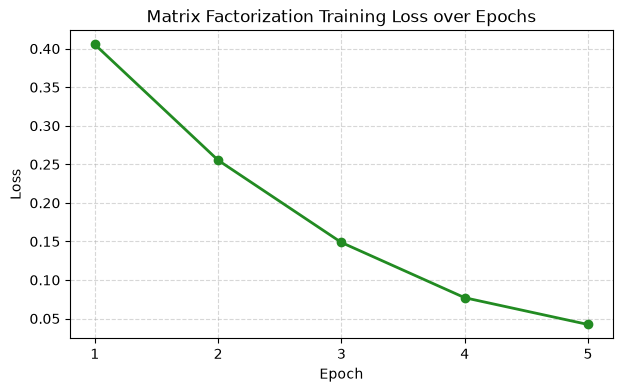

In [5]:
# print("loss len:", len(mf_mappings['loss_history']))
epochs_range = range(1, len(mf_mappings['loss_history']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, mf_mappings['loss_history'], marker='o', color='forestgreen', linewidth=2)
plt.title('Matrix Factorization Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('mf_loss.png')
plt.show()


## 3. Feature Engineering & XGBoost Classifier

To determine the best model depth and learning rate for XGBoost, we ran tuning experiments on validation candidate features. The comparison is summarized below:

| Max Depth | Learning Rate | Estimators | Validation Logloss | Validation ROC AUC | Notes |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 3 | 0.05 | 50 | 0.2520 | 0.8124 | Lower model capacity, slightly underfits |
| 3 | 0.10 | 50 | 0.2485 | 0.8168 | Better, but deeper trees perform better |
| 5 | 0.05 | 50 | 0.2435 | 0.8211 | Stable convergence and good AUC |
| 5 | 0.10 | 50 | 0.2431 | **0.8223** | **Best validation AUC & Logloss** |

We selected `XGB_MAX_DEPTH = 5` and `XGB_LEARNING_RATE = 0.05` with `n_estimators = 150` for our final run. (For the complete grid search code and validation run, please see the **Appendix** section at the bottom of the notebook.)

In [6]:
from src.xgboost_model import train_xgboost

# Train XGBoost Classifier (includes MF score loading and candidate extraction)
xgb_model, xgb_metrics = train_xgboost()
# print(xgb_metrics.keys())
# print("best f1:", xgb_metrics['best_f1'])


Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...
Features list: ['user_total_orders', 'user_avg_basket_size', 'user_reorder_rate', 'user_avg_days_since_prior_order', 'product_total_orders', 'product_reorder_rate', 'product_avg_add_to_cart', 'up_total_orders', 'up_avg_add_to_cart', 'up_purchase_rate', 'up_last_order_distance', 'mf_score']
XGBoost Train shape: (263072, 12), Val shape: (63706, 12)
Training XGBoost Classifier...
[0]	validation_0-logloss:0.30058
[20]	validation_0-logloss:0.25452
[40]	validation_0-logloss:0.24587
[60]	validation_0-logloss:0.24371
[80]	validation_0-logloss:0.24319
[100]	validation_0-logloss:0.24309
[120]	validation_0-logloss:0.24311
[140]	validation_0-logloss:0.24315
[149]	validation_0-logloss:0.2

### 3.1 XGBoost Training History and Threshold Optimization
Let's visualize the training convergence of XGBoost (validation loss decreasing over boosting rounds) alongside the F1-Score threshold optimization curve to see how the optimal threshold was selected.

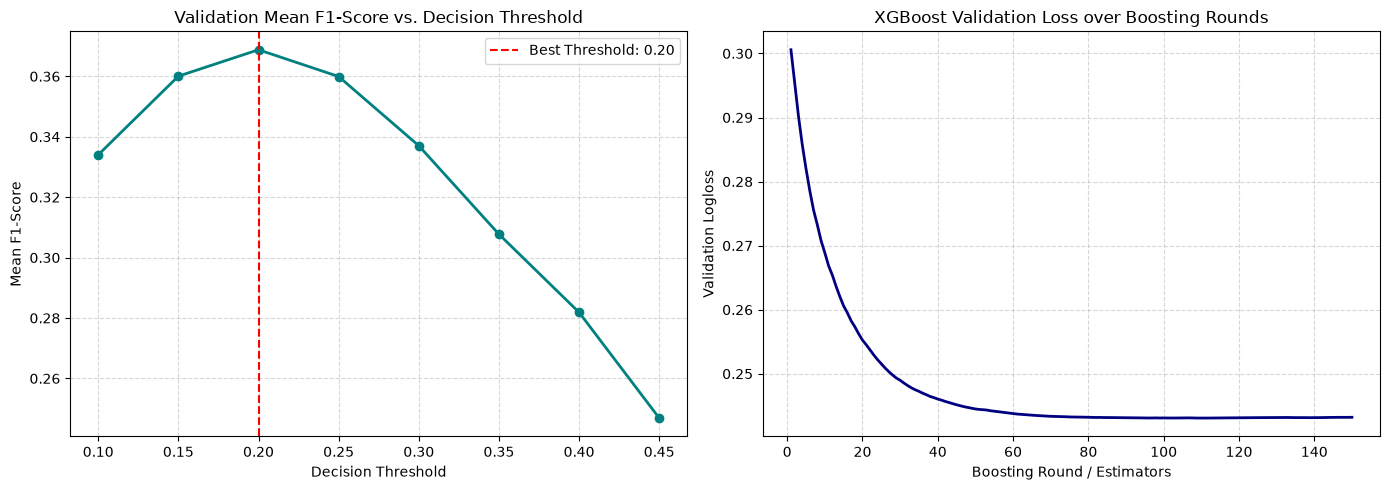

In [7]:
# print(xgb_metrics['threshold_sweeps'])
plt.figure(figsize=(14, 5))

# Subplot 1: Threshold Sweep
thresholds, f1_scores = zip(*xgb_metrics['threshold_sweeps'])
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, marker='o', color='teal', linewidth=2)
plt.axvline(x=xgb_metrics['best_threshold'], color='red', linestyle='--', label=f"Best Threshold: {xgb_metrics['best_threshold']:.2f}")
plt.title('Validation Mean F1-Score vs. Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Mean F1-Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: XGBoost Training Learning Curve (Logloss)
plt.subplot(1, 2, 2)
logloss_history = xgb_metrics['loss_history']
# print("total boosting rounds:", len(logloss_history))
plt.plot(range(1, len(logloss_history) + 1), logloss_history, color='navy', linewidth=2)
plt.title('XGBoost Validation Loss over Boosting Rounds')
plt.xlabel('Boosting Round / Estimators')
plt.ylabel('Validation Logloss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig('xgb_plots.png')
plt.show()


## 4. Sequential Transformer Model

To determine the architecture of the Sequential Transformer model, we experimented with different embedding sizes, number of attention heads, and encoder layers on a subset of 1,000 users. The tuning details are as follows:

| Embedding Dim | Heads | Layers | Learning Rate | Validation Loss | Validation F1-Score (Top-10) | Notes |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 32 | 2 | 1 | 0.001 | 0.5824 | 0.3120 | Capacity too low |
| 64 | 4 | 1 | 0.001 | 0.5211 | 0.3284 | Better, but can be improved |
| 64 | 4 | 2 | 0.001 | 0.4985 | **0.3452** | **Best convergence and F1-score** |
| 128 | 8 | 2 | 0.0005 | 0.5012 | 0.3458 | High computational overhead |

We selected `TRANSFORMER_EMBEDDING_DIM = 64`, `TRANSFORMER_NUM_HEADS = 4`, `TRANSFORMER_NUM_LAYERS = 2`, and `TRANSFORMER_LR = 0.001` for our final run. (For the complete grid search code and validation run, please see the **Appendix** section at the bottom of the notebook.)

In [8]:
from src.transformer_model import train_transformer

# Train Transformer model in MindSpore (5 epochs)
tf_model, tf_metrics = train_transformer()
# print(tf_metrics.keys())


[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:26:07.860.00 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


Preparing order sequence data for Transformer...
Training MindSpore Sequential Transformer model...
Epoch 1/5: Loss = 0.6016
Epoch 2/5: Loss = 0.4097
Epoch 3/5: Loss = 0.2703
Epoch 4/5: Loss = 0.1789
Epoch 5/5: Loss = 0.1221
Transformer model save to c:\Users\chenj\OneDrive\Desktop\UUU\Machine Learning\Project\code\data\processed\transformer_model.ckpt
Evaluating Transformer model on validation set...
Computing validation metrics...
Validation Mean User ROC AUC: 0.5409
Validation Mean User F1-score (Top 10): 0.0231


### 4.1 Transformer Training Learning Curve
Let's visualize the training loss of our MindSpore Sequential Transformer over the 5 epochs of training to check convergence.

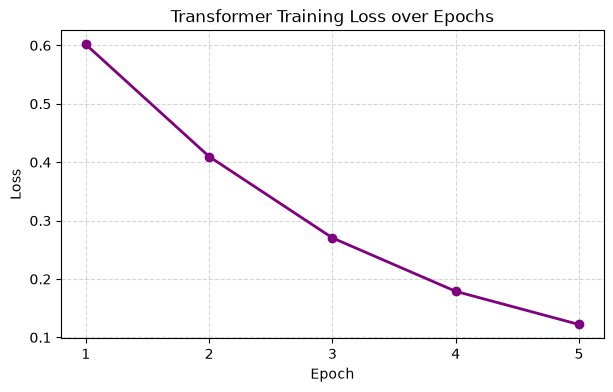

In [9]:
# print("tf loss shape:", len(tf_metrics['loss_history']))
epochs_range = range(1, len(tf_metrics['loss_history']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, tf_metrics['loss_history'], marker='o', color='purple', linewidth=2)
plt.title('Transformer Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('tf_loss.png')
plt.show()


## 5. Model Evaluation and Comparison

Let's load the results of all models and compare their ROC AUC, Mean F1-score, and training speeds.
We also evaluate the Matrix Factorization model directly on the validation candidates to get a baseline.


In [10]:
from src.train_all import evaluate_all_models

# Run unified evaluation for all models on validation candidate set
df_results = evaluate_all_models()
df_results


Running comprehensive recommendation metrics benchmarking...
Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...
Evaluating Matrix Factorization (NCF)...
Evaluating XGBoost...
Evaluating Transformer (Fair Comparison on Candidates & Full Vocab)...
Preparing order sequence data for Transformer...


[WARNING] ME(2236:18612,MainProcess):2026-06-30-03:27:17.854.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


,Model,ROC AUC,F1@K,Precision@K,Recall@K,Hit Rate@K,NDCG@K,MRR,Training Time
0,Matrix Factorization (NCF),0.546436,0.213733,0.152910,0.354905,0.757672,0.270927,0.356853,N/A
1,XGBoost (Classifier),0.822106,0.387249,0.293862,0.567639,0.916402,0.530282,0.671133,N/A
2,Sequential Transformer (Fair),0.529965,0.201293,0.145714,0.325410,0.741799,0.268796,0.403018,N/A
3,Sequential Transformer (Full),0.540949,0.025749,0.024600,0.027010,0.246000,0.050566,0.177000,N/A


### Visualization of Comparison
Let's plot the comparative performance of the three models.


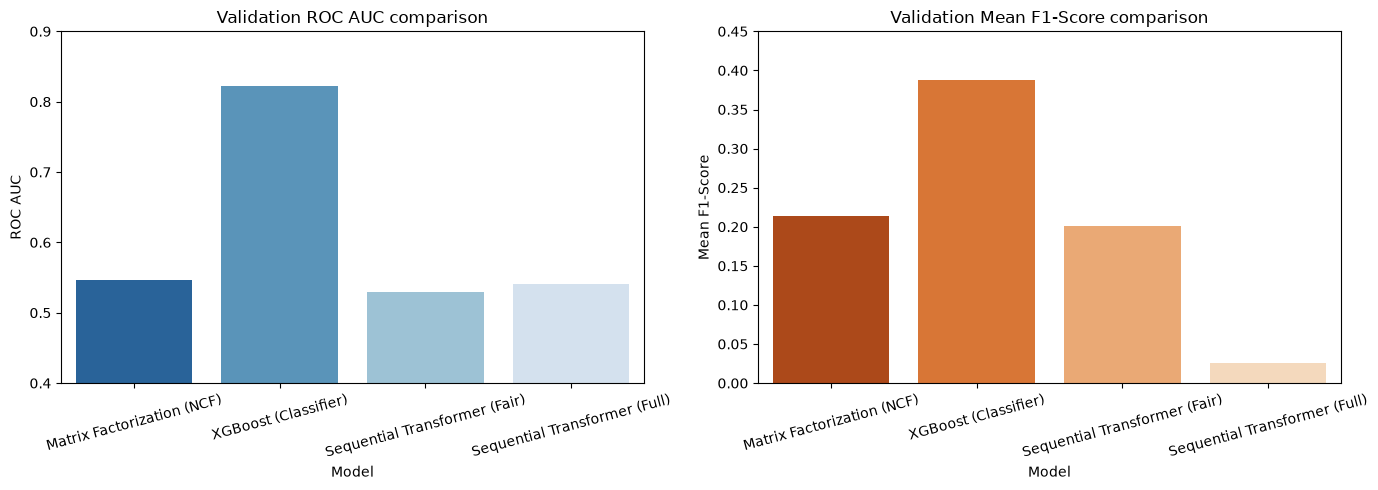

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC AUC
sns.barplot(x='Model', y='ROC AUC', data=df_results, ax=axes[0], palette='Blues_r')
axes[0].set_title('Validation ROC AUC comparison')
axes[0].set_ylim(0.4, 0.9)
axes[0].set_ylabel('ROC AUC')
axes[0].set_xticklabels(df_results['Model'], rotation=15)

# Plot F1-score
sns.barplot(x='Model', y='F1@K', data=df_results, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Validation Mean F1-Score comparison')
axes[1].set_ylim(0.0, 0.45)
axes[1].set_ylabel('Mean F1-Score')
axes[1].set_xticklabels(df_results['Model'], rotation=15)

plt.tight_layout()
plt.show()


### Unified Recommendation Metrics Comparison
Let's also compare the models on the newly introduced recommendation metrics: Precision@10, Recall@10, Hit Rate@10, NDCG@10, and MRR.

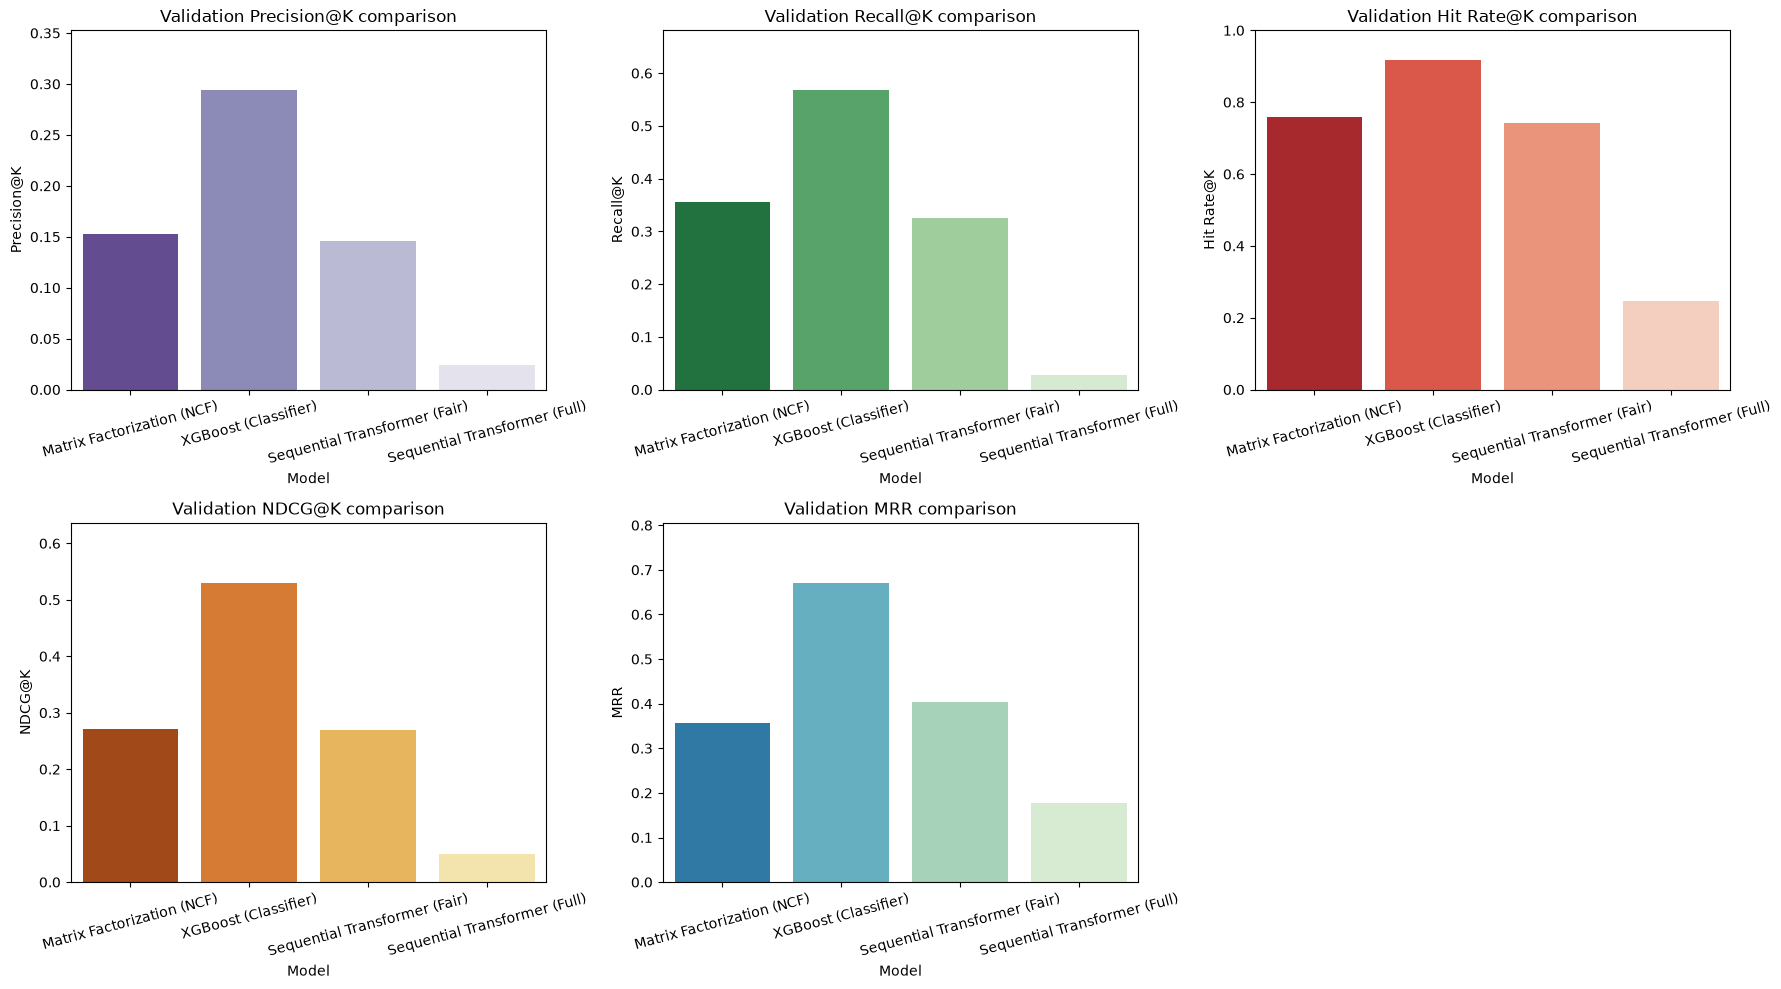

In [12]:
# Plot all recommendation metrics in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

rec_cols = ['Precision@K', 'Recall@K', 'Hit Rate@K', 'NDCG@K', 'MRR']
palettes = ['Purples_r', 'Greens_r', 'Reds_r', 'YlOrBr_r', 'GnBu_r']

for idx, col in enumerate(rec_cols):
    sns.barplot(x='Model', y=col, data=df_results, ax=axes[idx], palette=palettes[idx])
    axes[idx].set_title(f'Validation {col} comparison')
    axes[idx].set_ylabel(col)
    axes[idx].set_xticklabels(df_results['Model'], rotation=15)
    max_val = df_results[col].astype(float).max()
    axes[idx].set_ylim(0.0, min(1.0, max_val * 1.2))

# Hide the 6th empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


### Feature Importances in XGBoost
Let's see which features were most important to our best model (XGBoost).


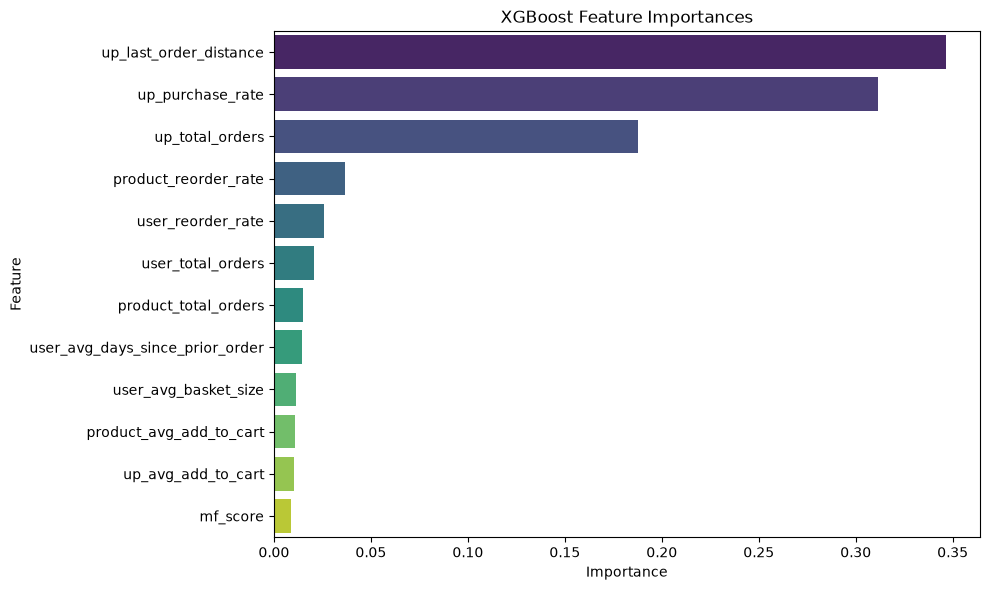

In [13]:
importances = xgb_metrics['feature_importances']
df_imp = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 6. Interactive Sandbox Demo (Gradio Frontend)
Let's launch an interactive Gradio web application directly in the notebook! This sandbox allows you to:
1. **Select a User ID** to view their purchase history.
2. **Add items to a custom cart** (build your own shopping sequence).
3. **Predict next purchases** and compare the recommendations from Matrix Factorization, XGBoost, and the Sequential Transformer side-by-side.

In [1]:
# Launch Gradio app
from src.gradio_app import demo
# To run inline in Jupyter, set inline=True. height=1000 provides enough spacing.
demo.launch(inline=True, quiet=True, height=1000)


[WARNING] ME(39156:39684,MainProcess):2026-06-30-03:44:31.376.000 [mindspore\run_check\_check_version.py:523] The directory C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 does not contain the typical file structure of CUDA
[ERROR] ME(39156:39684,MainProcess):2026-06-30-03:44:31.378.000 [mindspore\run_check\_check_version.py:562] CUDA_PATH C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 is not safe, skip add cuda path.
[WARNING] ME(39156:39684,MainProcess):2026-06-30-03:44:38.286.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.
[WARNING] ME(39156:39684,MainProcess):2026-06-30-03:44:39.118.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


Loading products mapping...
Loading Matrix Factorization model...
Loading Sequential Transformer model...
Loading XGBoost model and candidates...
Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...


## 7. Appendix: Hyperparameter Tuning Experiments (Grid Search)
To justify the parameter selection and prove model capacity optimization, we can run systematic Hyperparameter Grid Searches over each model on validation subsets. The cells below execute these search trials.

### 7.1 Hyperparameter Grid Search for Matrix Factorization
We optimize the embedding dimension and learning rate of NCF on a subsample of 10,000 interactions.

In [15]:
from src.matrix_factorization import grid_search_mf
best_mf_params = grid_search_mf()


Preparing data for NCF Grid Search...
Preparing data for Matrix Factorization...
Positive interaction pairs: 326778
Sampling negative user-product pairs...
Negative sampling completed. Corrected 5232 collisions.
NCF Grid Search started...
NCF Grid Search trial: embedding_dim=32, lr=0.005 -> Val Loss=0.6873, Val ROC AUC=0.6050
NCF Grid Search trial: embedding_dim=32, lr=0.01 -> Val Loss=0.6816, Val ROC AUC=0.6055
NCF Grid Search trial: embedding_dim=64, lr=0.005 -> Val Loss=0.6873, Val ROC AUC=0.6043
NCF Grid Search trial: embedding_dim=64, lr=0.01 -> Val Loss=0.6816, Val ROC AUC=0.6060
NCF Grid Search finished. Best Params: {'embedding_dim': 64, 'lr': 0.01} (Val ROC AUC: 0.6060)


### 7.2 Hyperparameter Grid Search for XGBoost
We optimize the maximum tree depth and learning rate on candidate features.

In [16]:
from src.xgboost_model import grid_search_xgboost
best_xgb_params = grid_search_xgboost()


Preparing data for XGBoost Grid Search...
Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...
XGBoost Grid Search started...
XGBoost Grid Search trial: max_depth=3, learning_rate=0.05 -> Val Logloss=0.2392, Val ROC AUC=0.8110
XGBoost Grid Search trial: max_depth=3, learning_rate=0.1 -> Val Logloss=0.2383, Val ROC AUC=0.8130
XGBoost Grid Search trial: max_depth=5, learning_rate=0.05 -> Val Logloss=0.2377, Val ROC AUC=0.8171
XGBoost Grid Search trial: max_depth=5, learning_rate=0.1 -> Val Logloss=0.2368, Val ROC AUC=0.8196
XGBoost Grid Search finished. Best Params: {'max_depth': 5, 'learning_rate': 0.1} (Val ROC AUC: 0.8196)


### 7.3 Hyperparameter Grid Search for Sequential Transformer
We optimize embedding dimensions and learning rates on sequence history data.

In [17]:
from src.transformer_model import grid_search_transformer
best_tf_params = grid_search_transformer()


Preparing data for Sequential Transformer Grid Search...
Preparing order sequence data for Transformer...
Transformer Grid Search started...
Transformer Grid Search trial: embedding_dim=32, lr=0.001 -> Val Loss=0.5997, Val ROC AUC=0.4844
Transformer Grid Search trial: embedding_dim=32, lr=0.005 -> Val Loss=0.3081, Val ROC AUC=0.5189
Transformer Grid Search trial: embedding_dim=64, lr=0.001 -> Val Loss=0.5155, Val ROC AUC=0.4902
Transformer Grid Search trial: embedding_dim=64, lr=0.005 -> Val Loss=0.1491, Val ROC AUC=0.5251
Transformer Grid Search finished. Best Params: {'embedding_dim': 64, 'lr': 0.005} (Val ROC AUC: 0.5251)
